In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pickle

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm

from gallifrey.gps import whitened_residuals, predictive_distribution
from gallifrey.transit import example_lightcurve, example_transit_model
from gallifrey.util import (
    plot_allan_deviation,
    plot_masks,
    plot_prediction,
    plot_residuals,
)

In [4]:
rng_key = jax.random.PRNGKey(42)

plt.style.use("../figures/gpjax.mplstyle")
cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

## TRANSIT PARAMETER POSTERIOR (WHITE NOISE)

In [4]:
models = {
    name: np.load(
        f"../data/processed/toy_data/mcmc_chains/{model}_parameter.npy",
    )
    for name, model in zip(
        ["Learned", "Periodic", "RBF"],
        ["gpmodel", "gpmodel_periodic_kernel", "gpmodel_rbf_kernel"],
    )
}
ground_truth = [0.1, 0.1, 0.3]

In [5]:
dfs = []
names = ["Learned", "Periodic", "RBF"]
for name, model in models.items():
    df = pd.DataFrame(model, columns=["radius ratio", "$u_1$", "$u_2$"])
    df["Kernel"] = name
    dfs.append(df)
df = pd.concat(dfs)

/home/chris/mambaforge/envs/gallifrey/lib/python3.10/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


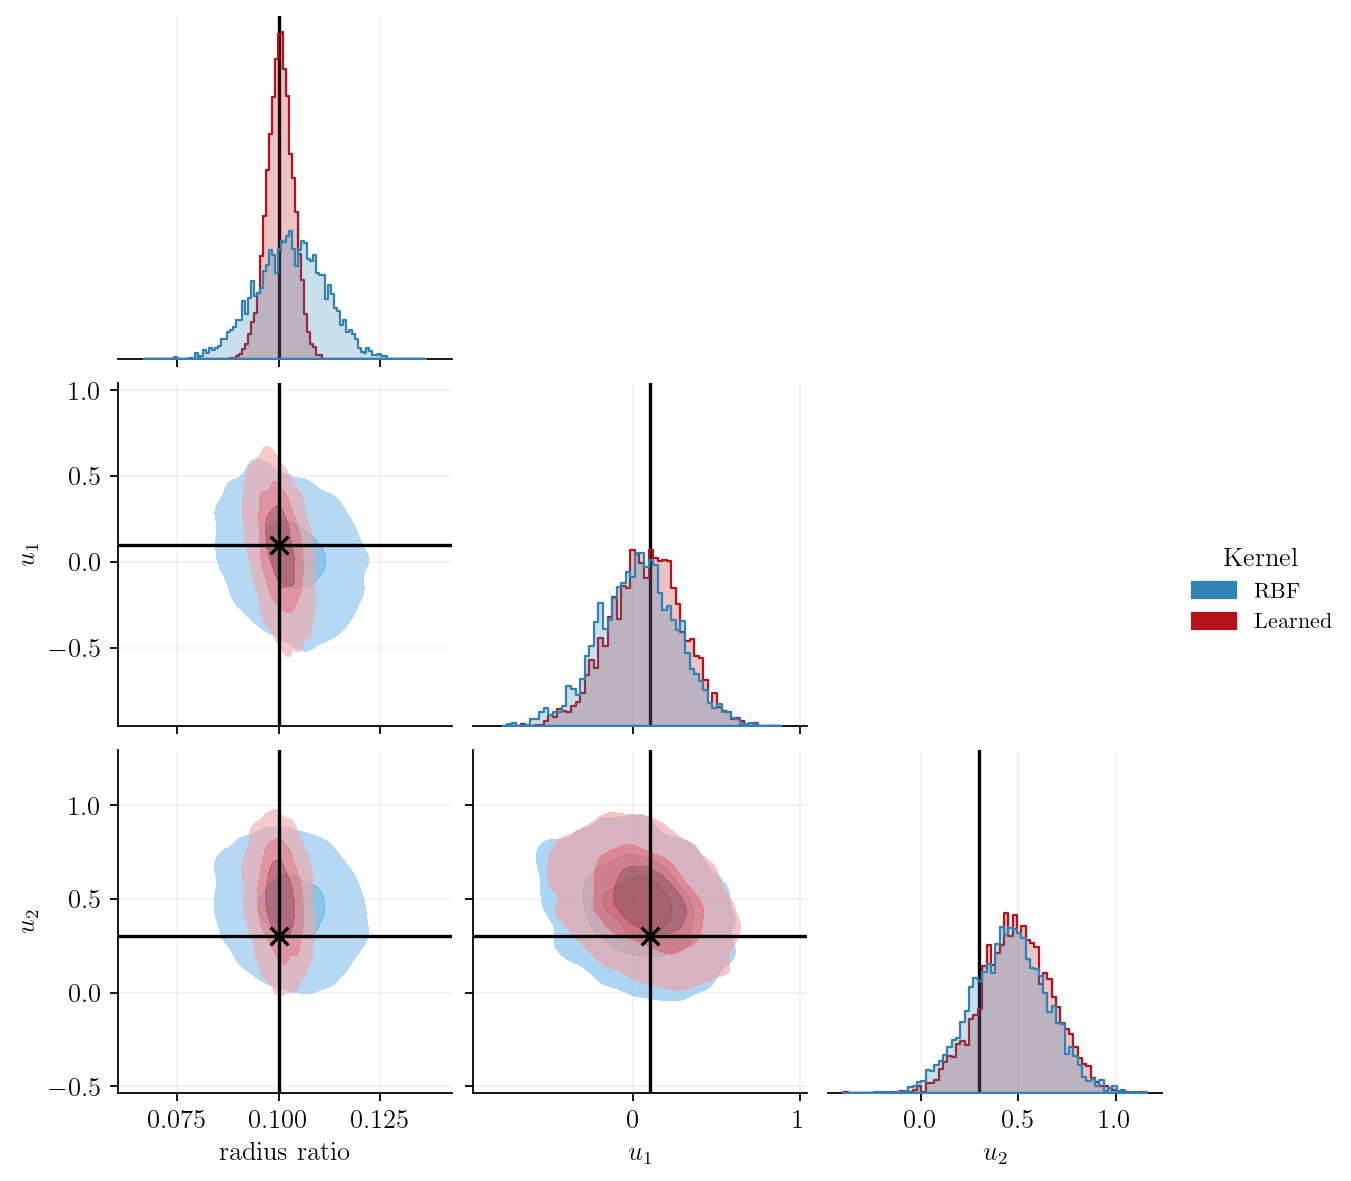

In [6]:
plot = sns.pairplot(
    df,
    corner=True,
    hue="Kernel",
    hue_order=["RBF", "Learned"],
    diag_kind="hist",
    kind="kde",
    diag_kws={"element": "step"},
    plot_kws={"fill": True, "alpha": 0.6, "levels": 4},
)

# Iterate over the axes
for i in range(3):
    for j in range(3):
        if plot.axes[i, j]:
            plot.axes[i, j].axvline(ground_truth[j], color="k")
            if i != j:
                plot.axes[i, j].scatter(ground_truth[j], ground_truth[i], color="k")
                plot.axes[i, j].axhline(ground_truth[i], color="k")

plot.figure.savefig("../figures/004_plots/toy_example_corner.pdf")

## AR NOISE

In [5]:
example = example_lightcurve(correlated=True)

In [6]:
lc_parameter = np.load(
    "../data/processed/toy_data/mcmc_chains/gpmodel_ar_noise_parameter.npy"
)
gp_parameter = np.load(
    "../data/processed/toy_data/mcmc_chains/gpmodel_ar_noise_parameter_gp.npy"
)
with open("../data/processed/toy_data/gp_models/gpmodel_ar_noise", "rb") as file:
    gpmodel_ar = pickle.load(file)

parameter_sample = lambda key, num: jax.random.choice(
    key, len(gp_parameter), shape=(num,)
)

In [7]:
df = pd.DataFrame(lc_parameter, columns=["radius ratio", "$u_1$", "$u_2$"])
df.describe()

,radius ratio,$u_1$,$u_2$
count,4000.000000,4000.000000,4000.000000
mean,0.100959,0.065244,0.471283
std,0.003632,0.231871,0.193668
min,0.087871,-0.666382,-0.234742
25%,0.098523,-0.088043,0.337671
50%,0.101081,0.074346,0.472374
75%,0.103484,0.225121,0.603289
max,0.113196,0.813174,1.140909


### Model Prediction

In [10]:
rng_key, sample_key = jax.random.split(rng_key)

samples_with_transit = []
samples_without_transit = []
for idx in tqdm(parameter_sample(sample_key, 500)):
    rng_key, sample_key = jax.random.split(rng_key)
    dist = predictive_distribution(
        gpmodel_ar,
        example["t"],
        X=example["t_sample"][example["transit_mask_sample"]],
        y=example["lc_sample"][example["transit_mask_sample"]],
        transit_model=example_transit_model,
        transit_parameter=lc_parameter[idx],
        gp_parameter=gp_parameter[idx],
    )
    sample = dist.sample(seed=sample_key)

    samples_with_transit.append(sample)
    samples_without_transit.append(
        sample - example_transit_model(example["t"], lc_parameter[idx])
    )
    del dist

100%|██████████| 500/500 [03:48<00:00,  2.18it/s]


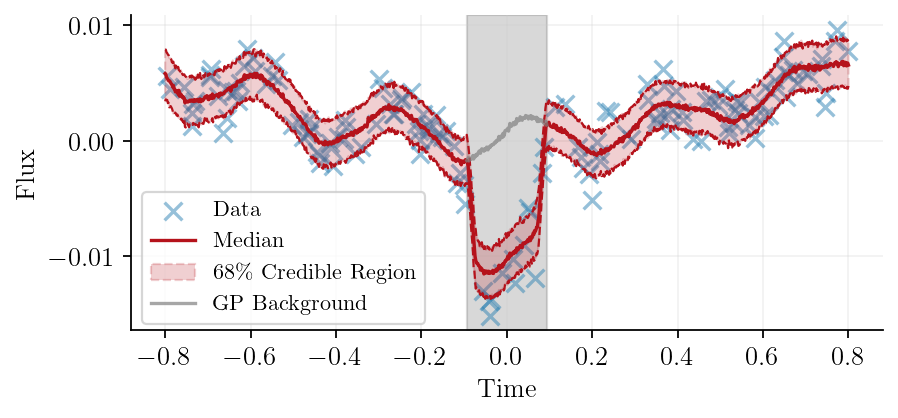

: 

In [20]:
fig, ax = plt.subplots()
ax.scatter(
    example["t_sample"],
    example["lc_sample"],
    label="Data",
    color=cols[0],
    alpha=0.5,
)

ax = plot_prediction(
    ax,
    example["t"],
    jnp.array(samples_with_transit),
    errorbar=68,
)
ax = plot_prediction(
    ax,
    example["t"][~example["transit_mask"]],
    jnp.array(samples_without_transit)[:, ~example["transit_mask"]],
    kws_mean={"color": "grey", "label": "GP Background", "alpha": 0.7},
)
ax = plot_masks(ax, example["t"], example["transit_mask"])


ax.legend(loc="center left", bbox_to_anchor=(0, 0.23))
ax.set_ylabel("Flux")
ax.set_xlabel("Time")
fig.savefig("../figures/004_plots/model_distribution_ar_noise.pdf")

### Residuals

In [8]:
rng_key, sample_key = jax.random.split(rng_key)
res = []
for idx in tqdm(parameter_sample(sample_key, 500)):
    rng_key, sample_key = jax.random.split(rng_key)
    dist = predictive_distribution(
        gpmodel_ar,
        example["t_sample"],
        X=example["t_sample"][example["transit_mask_sample"]],
        y=example["lc_sample"][example["transit_mask_sample"]],
        transit_model=example_transit_model,
        transit_parameter=lc_parameter[idx],
        gp_parameter=gp_parameter[idx],
    )
    res.append(whitened_residuals(example["lc_sample"], dist))

residuals = jnp.array(res)

100%|██████████| 500/500 [01:49<00:00,  4.58it/s]


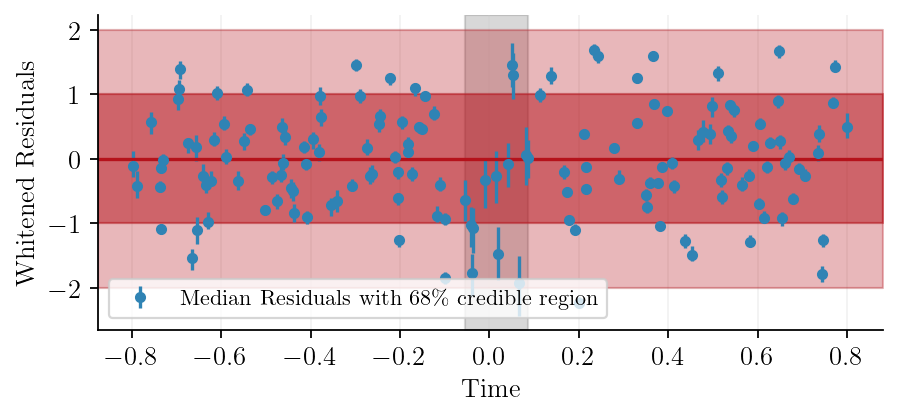

In [9]:
fig, ax = plt.subplots()

ax = plot_residuals(ax, example["t_sample"], residuals, credible_region=68)
ax = plot_masks(ax, example["t_sample"], example["transit_mask_sample"])

ax.legend(loc="center left", bbox_to_anchor=(0, 0.1))
ax.set_ylabel("Whitened Residuals")
ax.set_xlabel("Time")
fig.savefig("../figures/004_plots/residuals_ar_noise.pdf")

### Allan Deviation

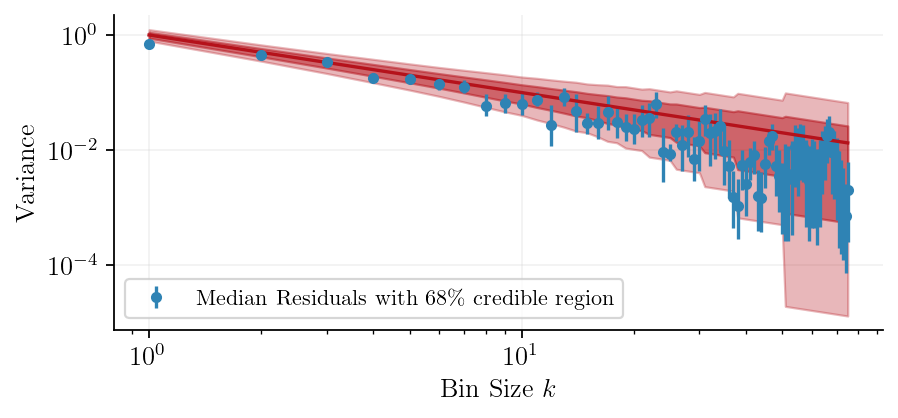

In [10]:
plt.style.use("../figures/gpjax.mplstyle")

fig, ax = plt.subplots()
plot_allan_deviation(ax, residuals, credible_region=68)


ax.legend(loc="center left", bbox_to_anchor=(0, 0.1))
ax.set_ylabel("Variance")
ax.set_xlabel(r"Bin Size $k$")
fig.savefig("../figures/004_plots/allandev_ar_noise.pdf")